In [1]:
from safetensors.torch import load_file

# # Path to the .safetensors file
# file_path = "experiment_saves/taxa-mask-30-locexc/finetune/test-bmi_lolr/best_model/model.safetensors"
# weights = load_file(file_path)
# emb_matrix = weights["base_model.encoder.embedding.weight"]

# Path to the .safetensors file
file_path = "experiment_saves/taxa-mask-30-locexc/model_checkpoints/best_model/model.safetensors"
weights = load_file(file_path)
emb_matrix = weights["encoder.embedding.weight"]

In [2]:
import anndata

adata = anndata.read_h5ad("experiment_saves/finetune_newsplit/data_checkpoint/augmented_data_finetune.h5ad")
taxa_list = adata.var_names.tolist()

In [3]:
print(emb_matrix.shape)
print(len(taxa_list))

torch.Size([4683, 128])
4680


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap

# --------------------
# Inputs
# --------------------
# embeddings: shape (N, D)
# taxa_list: list of N taxon strings like "Bacteria.Actinomycetota.Coriobacteriia..."
# Set your own file loading here:
# embeddings = np.load("taxa_embeddings.npy")
# taxa_list = open("taxa_list.txt").read().splitlines()

# If last entries are mask/pad/class
exclude_last = 3
embeddings = emb_matrix[:-exclude_last]

# --------------------
# Choose taxonomy level to color by
# --------------------
def extract_level(taxon, level=1, sep="."):
    """Extract a specific hierarchical level from a taxon string."""
    parts = taxon.split(sep)
    return parts[level] if level < len(parts) else "Unknown"

# Example: level=1 → phylum (index 0=Bacteria/Archaea, 1=phylum)
taxa_level_labels = np.array([[extract_level(t, level=color_level) for t in taxa_list] for color_level in range(4)])

In [5]:
# orange = ["Armatimonadota", "Asgardarchaeota", "Atribacterota", "BHI80-139", "Bacillota"]
# classes = ["Chlamydiia", "Chitninivibrionia", "Chlorobia", "Chloroflexia", "Chthonomonadia", "Cloacimonadia", "Clostridia", "Coprothermobacteria", "Coriobacteriia", "Cyanobacteriia", "D8A-2"]
# classes = ["BD2-11 terrestrial group", "BD7-11", "BMS9AB35", "BRH-c20a", "Babeliae", "Bacilli", "Bacteriovoracia", "Bacteroidia", "Balneolia", "Bathyarchaeia"]
classes = ["Bacillota", "Bacteroidota", "Actinomycetota", "Pseudomonadota"]

# mask = np.isin(taxa_level_labels[1], classes)
# print(mask.shape)
# print(embeddings.shape, len(taxa_level_labels))
# embeddings = embeddings[mask]
# taxa_level_labels = taxa_level_labels[:, mask]

print(embeddings.shape, len(taxa_level_labels))



torch.Size([4680, 128]) 4


In [21]:
# --------------------
# Run UMAP
# --------------------
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=40
)
umap_2d = reducer.fit_transform(embeddings)

from sklearn.manifold import TSNE

# --------------------
# Run t-SNE
# --------------------
tsne = TSNE(
    n_components=2,
    perplexity=10,       # similar to n_neighbors in UMAP
    learning_rate=200,
    metric="cosine",     # can also be "euclidean"
    random_state=40,
    init="pca",          # good starting point for t-SNE
)
tsne_2d = tsne.fit_transform(embeddings)


/home/kchen13/hmbenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [27]:
import numpy as np
import matplotlib.pyplot as plt

def plot_umap_taxonomy_colored(
    emb_2d,
    taxa_level_labels,
    color_level=None,
    classes_to_plot=None,
    colormap=plt.cm.tab20,
    point_size=10,
    alpha=0.8,
    colors=None,
):
    """
    Plot UMAP embeddings colored by selected taxonomic labels.

    Args:
        emb_2d (np.ndarray): 2D embeddings, shape (N, 2).
        taxa_level_labels (list of str): Label for each point.
        color_level (int or None): Optional label to show in the title.
        classes_to_plot (list of str or None): If provided, only these labels are plotted.
        colormap: matplotlib colormap, default tab20.
        point_size (int): scatter plot point size.
        alpha (float): transparency for points.

    Returns:
        None (shows the plot)
    """
    taxa_level_labels = np.array(taxa_level_labels)

    # Filter classes if requested
    if classes_to_plot is not None:
        mask = np.isin(taxa_level_labels, classes_to_plot)
        emb_2d = emb_2d[mask]
        taxa_level_labels = taxa_level_labels[mask]

    plt.figure(figsize=(10, 8))
    unique_labels = sorted(set(taxa_level_labels))
    if colors is None:
        colors = colormap(np.linspace(0, 1, len(unique_labels)))
    label_to_color = dict(zip(unique_labels, colors))

    for label in unique_labels:
        idxs = (taxa_level_labels == label)
        plt.scatter(
            emb_2d[idxs, 0],
            emb_2d[idxs, 1],
            c=[label_to_color[label]],
            label=label,
            s=point_size,
            alpha=alpha,
            edgecolors='none'
        )

    title = f"UMAP of embeddings coloured by taxonomy level {color_level}" \
            if color_level is not None else "UMAP of embeddings coloured by taxonomy"
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=3)
    plt.tight_layout()
    plt.show()


def plot_umap_highlight_classes(
    emb_2d,
    taxa_level_labels,
    class_to_highlight,
    classes_to_plot=None,
    color_level=None,
    point_size=10,
    alpha=0.8,
    color='red'
):
    """
    Plot UMAP embeddings highlighting selected taxonomic classes.

    Args:
        emb_2d (np.ndarray): 2D embeddings, shape (N, 2).
        taxa_level_labels (list of str): Label for each point.
        class_to_highlight (list of str): Labels to highlight in red.
        color_level (int or None): Optional taxonomy level index for title.
        point_size (int): scatter plot point size.
        alpha (float): transparency for points.
    """
    taxa_level_labels = np.array(taxa_level_labels)
    mask_selected = np.isin(taxa_level_labels, [class_to_highlight])
    
    # Filter classes if requested
    if classes_to_plot is not None:
        mask = np.isin(taxa_level_labels, classes_to_plot)
        emb_2d = emb_2d[mask]
        taxa_level_labels = taxa_level_labels[mask]
        mask_selected = mask_selected[mask]

    plt.figure(figsize=(10, 8))

    # Plot all others in grey
    plt.scatter(
        emb_2d[~mask_selected, 0],
        emb_2d[~mask_selected, 1],
        c="lightgrey",
        label="Other",
        s=point_size,
        alpha=alpha,
        edgecolors="none"
    )

    # Plot selected in red
    plt.scatter(
        emb_2d[mask_selected, 0],
        emb_2d[mask_selected, 1],
        c=color,
        label=class_to_highlight,
        s=point_size,
        alpha=alpha,
        edgecolors="none"
    )

    title = (
        f"UMAP of embeddings, {class_to_highlight} highlighted"
        if color_level is not None
        else "UMAP of embeddings (highlighted classes)"
    )
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=3)
    plt.tight_layout()
    plt.show()


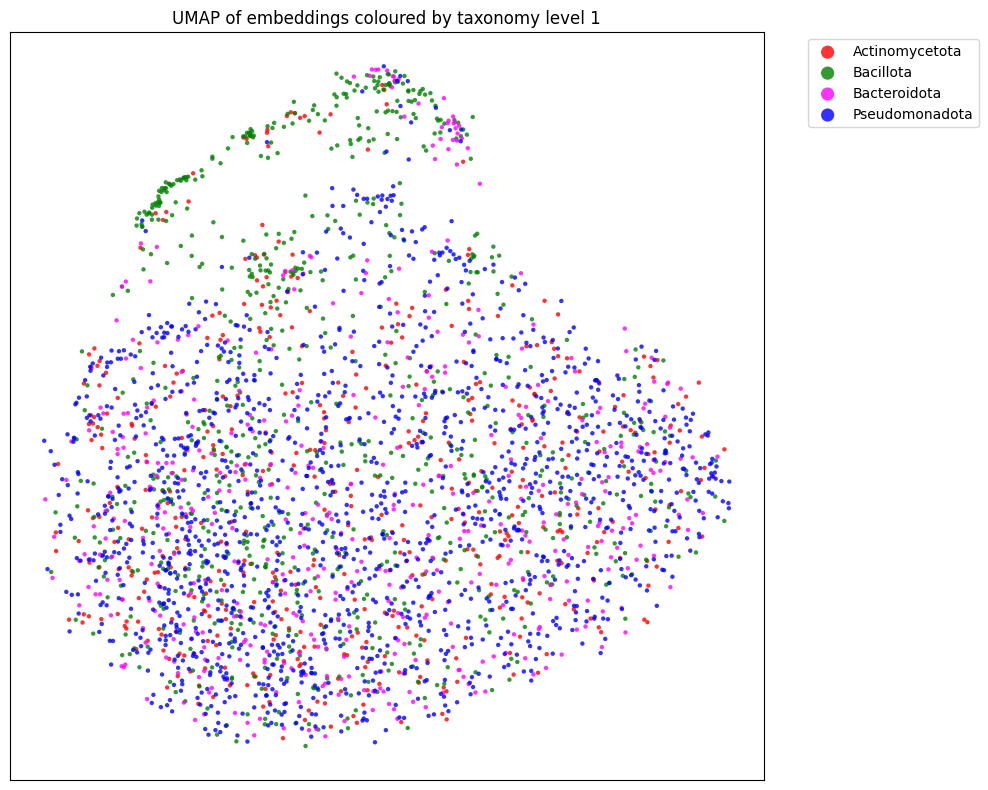

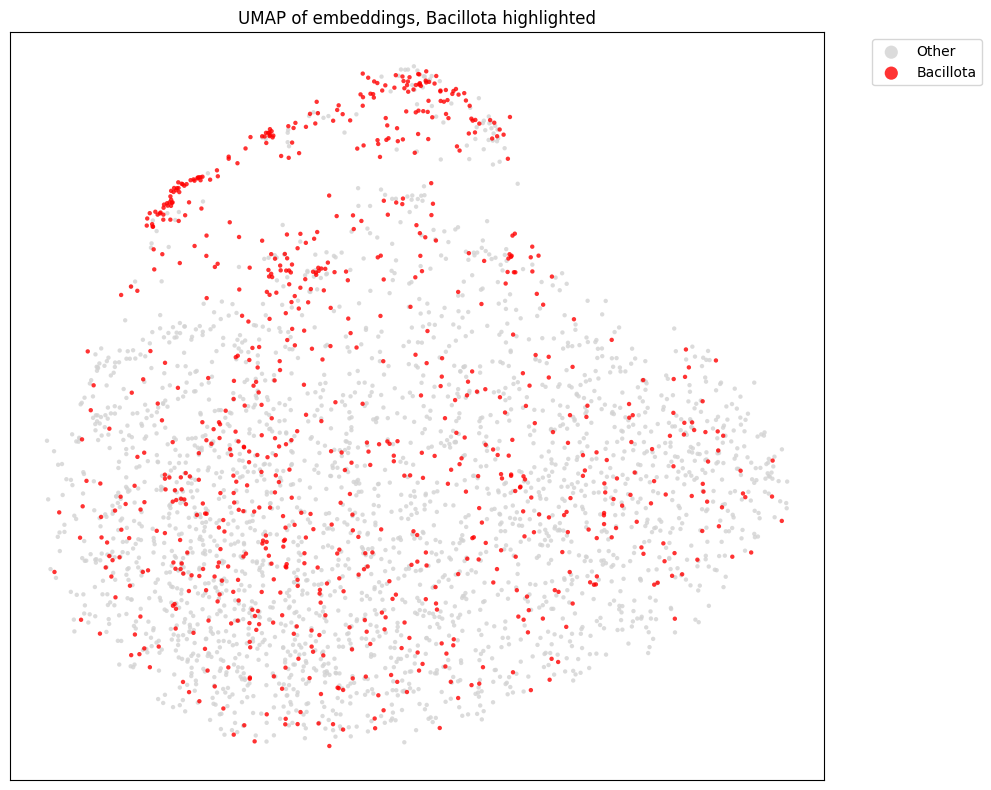

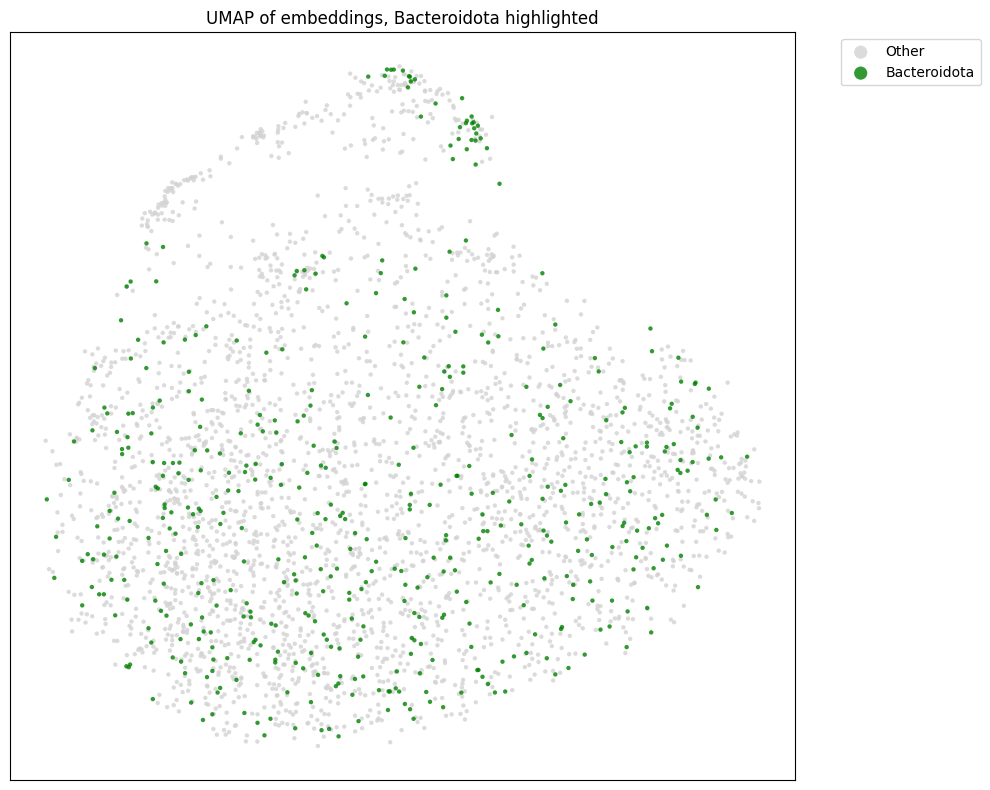

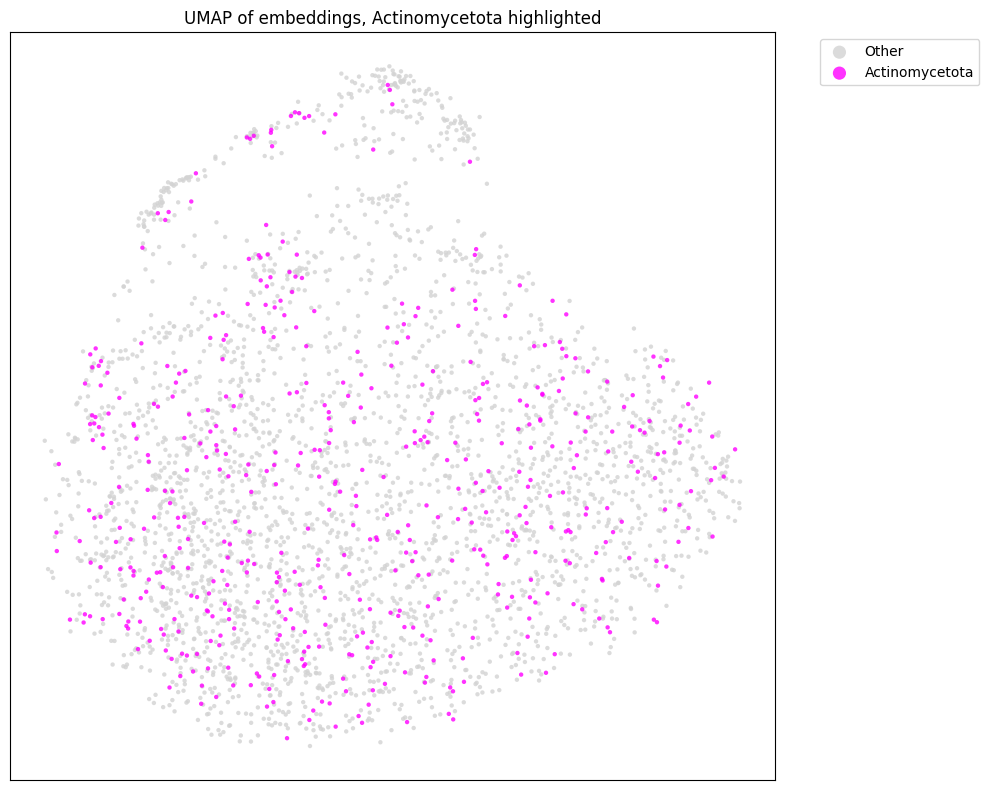

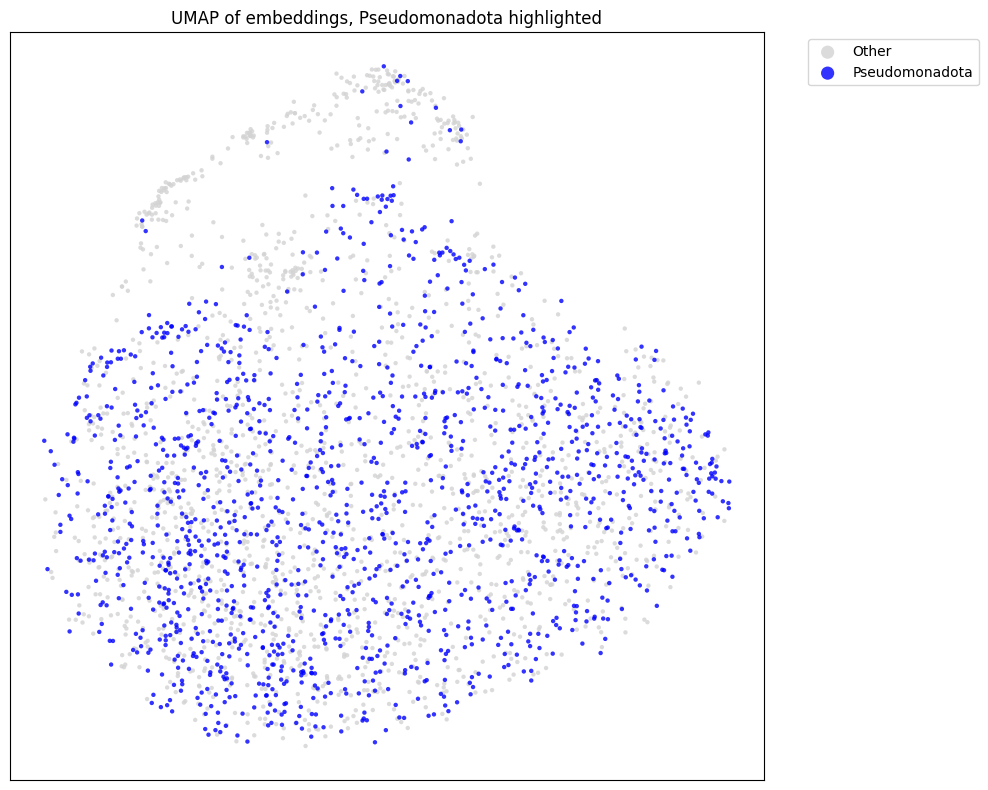

In [30]:
colors = ["red", "green",  "magenta", "blue"]


plot_umap_taxonomy_colored(
    umap_2d,
    taxa_level_labels[1],
    color_level=1,
    classes_to_plot=["Bacillota", "Bacteroidota", "Actinomycetota", "Pseudomonadota"],
    colors=colors,
)

for color, phylum in zip(colors, classes):
    plot_umap_highlight_classes(
        umap_2d,
        taxa_level_labels[1],  # full label list
        class_to_highlight=phylum,
        classes_to_plot=["Bacillota", "Bacteroidota", "Actinomycetota", "Pseudomonadota"],
        color_level=1,
        color=color,
    )

/home/kchen13/hmbenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


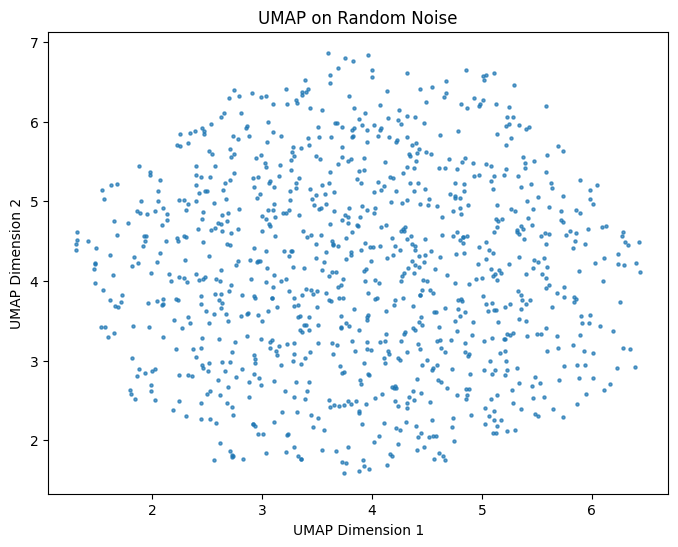

In [31]:
# Generate random noise data
random_data = np.random.rand(1000, 50)  # 1000 samples with 50 features each

# Apply UMAP
random_reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)
random_umap_2d = random_reducer.fit_transform(random_data)

# Plot the UMAP result
plt.figure(figsize=(8, 6))
plt.scatter(random_umap_2d[:, 0], random_umap_2d[:, 1], s=5, alpha=0.7)
plt.title("UMAP on Random Noise")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()